# Harford County (24025) — what happened to NAIP 2013?

> **Answered.** The 2013 crops over the affected Harford tracts are **solid black — every band, mean 0, std 0**. NAIP 2013 has a nodata hole over part of the county; the model scored blank images and returned its fixed response to them, `0.68359375`. Full argument and the fix in **section 7**. The rest of the notebook is the evidence trail.

**What the coefficient tables showed** (issue #36, Baltimore CSA arm):

* Predicted tract-mean wealth in Harford County jumps **+0.64** in 2013 and reverts **-0.52** in 2015. Every other county in the Baltimore CBSA moves +0.08 to +0.19 in 2013.
* It is a *subset* of the county: **24 of 57 Harford tracts** spike above +0.3 (mean +0.56, max +1.75), against **9 of 646** tracts everywhere else.
* 2013 is the only affected year — the same diagnostic for 2015 and 2017 is clean.
* `actual_year` in the prediction CSVs is **2013 for every Harford building**, so this is *not* the fetcher substituting a different flight year.

**The tell: the predictions are literally constant.** In 2013, **3,919 of 10,028 Harford buildings (39%) carry the identical value `0.68359375`**, and **17 of 57 Harford tracts have that value for every single building in them**. That value appears in 84 of 120,197 buildings (0.07%) everywhere else in 2013, and never more than ~185 times in any other Harford year. Harford also loses **1,762 of its 11,790 buildings** entirely in 2013.

A constant output across a contiguous block of tracts means the model saw identical inputs. Section 6 shows what they were: nothing at all.

**What this is NOT** (both checked, both ruled out — see section 7):

* not a boundless-read zero-fill — `partial_coverage` is `False` and `covers_window` is `True`;
* not a 3-band `visual` fallback — `nir_padded` is `False` and the 4-band `image` asset is present.

The STAC metadata looks perfectly healthy. Only the pixels reveal it, which is why no existing guard fired.

**What each section does**

| section | needs network | what it settles |
|---|---|---|
| 1, 2 | no | which tracts and buildings to look at |
| **2b** | **no** | **the constant-value signature, straight from the CSVs** |
| 3 | yes (metadata only) | asset availability, flight date, GSD, DOQQ footprint vs crop window |
| 4-5 | yes (pixels) | the crops themselves, with `partial` / `nir_padded` flags |
| **6** | **yes** | **per-band radiometry — this is where the all-zero crops show up** |
| 7 | no | the diagnosis and the guard to add |

Everything matches what the predictor did: `crop_size_meters = 2 * tau = 200 m`, `out_pixels = image_size = 224`, `nbands = 4`, `exact_year=True`.

In [1]:
import warnings

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pyproj import Transformer

from src import csa_event_study as ces
from src import evaluation as ev
from src.utils.paths import PROCESSED_DATA_DIR, RESULTS_DIR

# ── undo what importing src.evaluation does to matplotlib ────────────────────
# evaluation.py is a batch figure-generating script, so at import time (line 54)
# it calls matplotlib.use("Agg") and then loads paper.mplstyle. In a notebook
# that means:
#   (a) every figure renders to an offscreen buffer, so a cell ending in a
#       figure prints "<Figure size ... with N Axes>" and shows NOTHING; and
#   (b) text.usetex=True, which sends each label through LaTeX and fails on
#       ordinary characters — the underscore in "neighbour_24005", for one.
# Both must be reverted AFTER the import, since the import is what sets them.
%matplotlib inline
plt.style.use("default")
matplotlib.rcParams["text.usetex"] = False
print(f"backend: {matplotlib.get_backend()}   "
      f"usetex: {matplotlib.rcParams['text.usetex']}")

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)

RUN = RESULTS_DIR / "run_20260722"
SUSPECT_COUNTY = "24025"          # Harford
SPIKE_YEAR = 2013

# The panel to LOOK at. Deliberately not spec.panel_years: 2018 was dropped from
# the registry for being a one-year period on a biennial panel, but the imagery
# still exists and is worth eyeballing here.
PANEL_YEARS = [2011, 2013, 2015, 2017, 2018]

# What the predictor used (main.py: crop_size_meters = tau_meters * 2).
TAU_METERS = 100
CROP_SIZE_METERS = TAU_METERS * 2
OUT_PIXELS = 224
NBANDS = 4

N_SUSPECT_TRACTS = 3      # worst-spiking Harford tracts to show
N_BUILDINGS_PER_TRACT = 2

spec = ces.CSA_CITIES["baltimore"]
print(f"registry panel (2018 dropped): {spec.panel_years}")
print(f"inspecting:                    {PANEL_YEARS}")

backend: inline   usetex: False
registry panel (2018 dropped): (2011, 2013, 2015, 2017)
inspecting:                    [2011, 2013, 2015, 2017, 2018]


## 1. Rank tracts by the 2013 spike  *(offline)*

Spike = tract-mean prediction in 2013 minus the mean of its 2011 and 2015 values, so a genuine level trend cancels and only a transient shows.

In [2]:
bld = ev._csa_city_preds(RUN, spec, PANEL_YEARS)
bld["county"] = bld["GEOID_str"].str[:5]

tract_year = (bld.groupby(["county", "GEOID_str", "year"])["predicted_value"]
              .mean().unstack())
tract_year["spike"] = (tract_year[SPIKE_YEAR]
                       - 0.5 * (tract_year[2011] + tract_year[2015]))

print(f"{SPIKE_YEAR} spike per tract, by county")
display(tract_year.groupby("county")["spike"]
        .describe(percentiles=[.25, .5, .75, .9]).round(3))

harford = tract_year.xs(SUSPECT_COUNTY, level="county").sort_values("spike",
                                                                   ascending=False)
print(f"\nHarford tracts ranked by {SPIKE_YEAR} spike (worst 10)")
display(harford.head(10).round(3))

2013 spike per tract, by county


,count,mean,std,min,25%,50%,75%,90%,max
county,,,,,,,,,
24003,127.0,0.116,0.100,-0.059,0.035,0.105,0.183,0.250,0.487
24005,215.0,0.073,0.083,-0.130,0.016,0.069,0.128,0.184,0.310
24013,37.0,0.089,0.072,-0.010,0.023,0.073,0.137,0.180,0.291
24025,57.0,0.559,0.560,-0.069,0.157,0.244,1.062,1.433,1.754
24027,59.0,0.059,0.077,-0.184,0.037,0.059,0.110,0.151,0.187
24035,11.0,0.123,0.066,0.032,0.083,0.120,0.147,0.205,0.246
24510,197.0,-0.085,0.251,-0.994,-0.146,-0.023,0.061,0.150,0.435



Harford tracts ranked by 2013 spike (worst 10)


year,2011,2013,2015,2017,2018,spike
GEOID_str,,,,,,
24025302901,-1.146,0.684,-0.996,-0.864,-0.946,1.754
24025302902,-1.206,0.684,-0.832,-0.826,-0.818,1.703
24025301302,-1.036,0.684,-0.909,-0.853,-0.849,1.656
24025301105,-0.960,0.684,-0.953,-0.860,-0.867,1.640
24025301602,-0.975,0.684,-0.885,-0.858,-0.890,1.614
24025301704,-0.656,0.684,-0.865,-0.791,-0.809,1.444
24025302802,-0.856,0.684,-0.628,-0.607,-0.577,1.425
24025301401,-0.779,0.684,-0.556,-0.543,-0.547,1.351
24025301205,-0.639,0.684,-0.693,-0.476,-0.405,1.350


## 2. Pick tracts and buildings to look at  *(offline)*

Three groups, so the comparison is controlled:

* **suspect** — the worst-spiking Harford tracts
* **harford_clean** — a Harford tract that did *not* spike (isolates tile vs county)
* **neighbour** — a tract in an adjacent county (the normal case)

Buildings come from the same `buildings_index` the predictor sampled from, restricted to buildings that actually have a 2013 prediction, so we look at exactly what the model scored.

In [3]:
import pyarrow.dataset as ds

from src.csa_predict import BUILDINGS_PARQUET
from src.geo_utils import METRIC_CRS

suspect = harford.head(N_SUSPECT_TRACTS).index.tolist()
harford_clean = harford.tail(1).index.tolist()
neighbour = (tract_year.xs("24005", level="county")
             .assign(d=lambda d: d["spike"].abs()).nsmallest(1, "d").index.tolist())

groups = {**{g: "suspect" for g in suspect},
          **{g: "harford_clean" for g in harford_clean},
          **{g: "neighbour_24005" for g in neighbour}}
print(groups)

idx = ds.dataset(PROCESSED_DATA_DIR / BUILDINGS_PARQUET).to_table(
    columns=["building_id", "GEOID", "centroid_x", "centroid_y"]).to_pandas()
idx["GEOID"] = idx["GEOID"].astype(str)
idx = idx[idx["GEOID"].isin(groups)]

# keep only buildings the prediction pass actually scored in the spike year
scored = set(bld.loc[bld["year"] == SPIKE_YEAR, "building_id"])
idx = idx[idx["building_id"].isin(scored)]

to_4326 = Transformer.from_crs(METRIC_CRS, "EPSG:4326", always_xy=True)
targets = (idx.groupby("GEOID", group_keys=False)
           .head(N_BUILDINGS_PER_TRACT).reset_index(drop=True))
targets["lon"], targets["lat"] = to_4326.transform(
    targets["centroid_x"].to_numpy(), targets["centroid_y"].to_numpy())
targets["group"] = targets["GEOID"].map(groups)

# each target's own predicted value per year, to print under its image
pred_lookup = (bld.set_index(["building_id", "year"])["predicted_value"]
               .groupby(level=[0, 1]).mean())
display(targets[["building_id", "GEOID", "group", "lon", "lat"]])

{'24025302901': 'suspect', '24025302902': 'suspect', '24025301302': 'suspect', '24025301601': 'harford_clean', '24005402407': 'neighbour_24005'}


,building_id,GEOID,group,lon,lat
0,2340833174712340690,24005402407,neighbour_24005,-76.791183,39.337599
1,2340830215479886328,24005402407,neighbour_24005,-76.789806,39.348844
2,2341637194737822617,24025301302,suspect,-76.317116,39.433162
3,2341640321474016195,24025301302,suspect,-76.314941,39.434720
4,2341887829701973909,24025302901,suspect,-76.156622,39.507319
5,2341899438998582007,24025302901,suspect,-76.148708,39.512438
6,2341876817405822723,24025302902,suspect,-76.163541,39.504564
7,2341847701822514219,24025302902,suspect,-76.181275,39.499283


## 2b. The constant-value signature  *(offline — this is the actual finding)*

If a block of buildings all score identically, the model saw identical inputs. Nothing about real imagery does that. This cell locates the degenerate block and maps it, so section 3-5 know where to look.

In [4]:
# How many buildings share their exact predicted value, by county x year?
dup = (bld.groupby(["county", "year"])["predicted_value"]
       .agg(n="size", distinct="nunique",
            modal=lambda s: s.value_counts().index[0],
            modal_n=lambda s: s.value_counts().iloc[0]))
dup["modal_share"] = dup["modal_n"] / dup["n"]
print("modal predicted_value share — anything above a few % is degenerate")
display(dup.round(4).sort_values("modal_share", ascending=False).head(12))

# The constant itself, and which tracts are entirely made of it.
CONST = dup["modal_share"].idxmax()
const_val = dup.loc[CONST, "modal"]
print(f"\nworst cell: county {CONST[0]}, year {CONST[1]}, constant = {const_val!r}")

blk = bld[(bld["county"] == CONST[0]) & (bld["year"] == CONST[1])]
per_tract = blk.groupby("GEOID_str")["predicted_value"].agg(
    n="size", distinct="nunique",
    const_share=lambda s: (s == const_val).mean())
fully = per_tract.index[per_tract["distinct"] == 1].tolist()
print(f"tracts entirely constant: {len(fully)}/{len(per_tract)}")
display(per_tract.sort_values("const_share", ascending=False).head(20).round(3))

# Building counts by year — the same coverage failure should also show up as
# buildings that got no prediction at all.
print("\nbuildings scored per year (a drop = crops that failed outright)")
display(bld[bld["county"] == CONST[0]].groupby("year")["building_id"].nunique())

# Hand the degenerate tracts to the imagery sections.
CONST_TRACTS = fully
print(f"\nCONST_TRACTS -> {CONST_TRACTS[:5]}{' ...' if len(CONST_TRACTS) > 5 else ''}")

modal predicted_value share — anything above a few % is degenerate


n  distinct   modal  modal_n  modal_share
county year                                               
24025  2013  10028      3959  0.6836     3919       0.3908
       2017  11790      5739  0.6836      185       0.0157
       2011  11790      5613  0.6836      181       0.0154
       2018  11790      5735  0.6885      179       0.0152
       2015  11790      5778  0.6836      178       0.0151
24035  2017   2200      1819  1.0117        7       0.0032
       2018   2200      1845  1.2051        6       0.0027
       2013   2200      1849  1.0186        5       0.0023
       2015   2200      1875 -0.7798        4       0.0018
       2011   2200      1839  0.8447        4       0.0018
24027  2015  11763      5094  1.1377       20       0.0017
24005  2013  42413      8277  0.6836       73       0.0017


worst cell: county 24025, year 2013, constant = np.float64(0.68359375)
tracts entirely constant: 17/57


,n,distinct,const_share
GEOID_str,,,
24025301105,200,1,1.000
24025301205,145,1,1.000
24025301107,200,1,1.000
24025301108,200,1,1.000
24025301202,63,1,1.000
24025301204,9,1,1.000
24025301602,76,1,1.000
24025301401,3,1,1.000
24025301302,15,1,1.000



buildings scored per year (a drop = crops that failed outright)


year
2011    11790
2013    10028
2015    11790
2017    11790
2018    11790
Name: building_id, dtype: int64


CONST_TRACTS -> ['24025301105', '24025301107', '24025301108', '24025301202', '24025301204'] ...


## 3. STAC audit — coverage, assets, flight  *(needs network, metadata only)*

Three things to read here, in priority order:

1. **`covers_window`** — does the chosen DOQQ's own footprint actually contain the 200 m crop window? `False` means `read_naip_crop_from_src` reads `boundless=True, fill_value=0` and returns a partly-black crop that nothing downstream rejects. This is the leading hypothesis, and the suspect tracts should show `False` in 2013 and `True` in every other year.
2. **`has_image`** — `resolve_naip_item` takes `assets["image"]` (4-band) and falls back to `assets["visual"]` (3-band). On the fallback NIR is zero-filled and flagged `nir_padded`.
3. **`datetime` / `gsd`** — a leaf-off flight or a resolution change would also move predictions, though neither would make them *constant*.

In [5]:
from src.data.naip_fetcher import get_catalog, item_contains_bbox, lonlat_bbox

cat = get_catalog()
rows = []
for t in targets.itertuples():
    bbox = lonlat_bbox(t.lon, t.lat, CROP_SIZE_METERS)
    for year in PANEL_YEARS:
        items = list(cat.search(collections=["naip"], bbox=bbox,
                                datetime=f"{year}-01-01/{year}-12-31").items())
        if not items:
            rows.append(dict(GEOID=t.GEOID, group=t.group, year=year,
                             item_id=None, note="NO ITEM"))
            continue
        for it in items:
            props = it.properties
            rows.append(dict(
                GEOID=t.GEOID, group=t.group, year=year, item_id=it.id,
                # the decisive column: does this DOQQ actually cover the crop?
                covers_window=item_contains_bbox(it, bbox),
                has_image="image" in it.assets,
                assets=",".join(sorted(it.assets)),
                gsd=props.get("gsd"),
                datetime=str(props.get("datetime"))[:10],
                bands=len(props.get("eo:bands", [])) or None,
                note=""))

audit = pd.DataFrame(rows).drop_duplicates(["GEOID", "year", "item_id"])

print("share of items whose footprint COVERS the crop window, by group x year")
print("(any tract whose only items are False gets a zero-filled crop)")
display(audit.pivot_table(index="group", columns="year",
                          values="covers_window", aggfunc="max"))
print("\n4-band asset availability by group x year")
display(audit.pivot_table(index="group", columns="year",
                          values="has_image", aggfunc="max"))
print("\nfull detail")
display(audit.sort_values(["group", "year"])[
    ["group", "GEOID", "year", "item_id", "covers_window", "has_image",
     "datetime", "gsd", "bands", "assets"]])

share of items whose footprint COVERS the crop window, by group x year
(any tract whose only items are False gets a zero-filled crop)


year,2011,2013,2015,2017,2018
group,,,,,
neighbour_24005,True,True,True,True,True
suspect,True,True,True,True,True



4-band asset availability by group x year


year,2011,2013,2015,2017,2018
group,,,,,
neighbour_24005,True,True,True,True,True
suspect,True,True,True,True,True



full detail


,group,GEOID,year,item_id,covers_window,has_image,datetime,gsd,bands,assets
0,neighbour_24005,24005402407,2011,md_m_3907642_ne_18_1_20110630_20111116,True,True,2011-06-30,1.0,NaN,"image,metadata,rendered_preview,thumbnail,tile..."
1,neighbour_24005,24005402407,2013,md_m_3907642_ne_18_1_20130917_20131112,True,True,2013-09-17,1.0,NaN,"image,metadata,rendered_preview,thumbnail,tile..."
2,neighbour_24005,24005402407,2015,md_m_3907642_ne_18_1_20150724_20150914,True,True,2015-07-24,1.0,NaN,"image,metadata,rendered_preview,thumbnail,tile..."
3,neighbour_24005,24005402407,2017,md_m_3907642_ne_18_1_20170609_20170907,True,True,2017-06-09,1.0,NaN,"image,metadata,rendered_preview,thumbnail,tile..."
4,neighbour_24005,24005402407,2018,md_m_3907642_ne_18_060_20181121_20190212,True,True,2018-11-21,0.6,NaN,"image,metadata,rendered_preview,thumbnail,tile..."
10,suspect,24025301302,2011,md_m_3907638_sw_18_1_20110716_20111116,True,True,2011-07-16,1.0,NaN,"image,metadata,rendered_preview,thumbnail,tile..."
11,suspect,24025301302,2011,md_m_3907638_se_18_1_20110716_20111116,False,True,2011-07-16,1.0,NaN,"image,metadata,rendered_preview,thumbnail,tile..."
22,suspect,24025301302,2011,md_m_3907638_nw_18_1_20110716_20111116,False,True,2011-07-16,1.0,NaN,"image,metadata,rendered_preview,thumbnail,tile..."
23,suspect,24025301302,2011,md_m_3907638_ne_18_1_20110716_20111116,False,True,2011-07-16,1.0,NaN,"image,metadata,rendered_preview,thumbnail,tile..."
37,suspect,24025302901,2011,md_m_3907631_se_18_1_20110716_20111116,True,True,2011-07-16,1.0,NaN,"image,metadata,rendered_preview,thumbnail,tile..."


## 4. Fetch the crops the model saw  *(needs network)*

`exact_year=True` reproduces the predictor's guard: no same-year item gives `no_year_match` rather than silently substituting another flight.

In [6]:
from src.data.naip_fetcher import fetch_naip

crops, meta = {}, []
for t in targets.itertuples():
    for year in PANEL_YEARS:
        res = fetch_naip(lon=t.lon, lat=t.lat,
                         crop_size_meters=CROP_SIZE_METERS,
                         nbands=NBANDS, out_pixels=OUT_PIXELS,
                         year_hint=year, exact_year=True)
        crops[(t.building_id, year)] = res.crop
        meta.append(dict(
            building_id=t.building_id, GEOID=t.GEOID, group=t.group, year=year,
            actual_year=res.actual_year, failure=res.failure,
            nir_padded=res.nir_padded, partial=res.partial_coverage,
            pred=pred_lookup.get((t.building_id, year), np.nan)))

meta = pd.DataFrame(meta)
print("fetch outcomes — nir_padded / partial / failure are the ones to watch")
display(meta.round(3))

fetch outcomes — nir_padded / partial / failure are the ones to watch


,building_id,GEOID,group,year,actual_year,failure,nir_padded,partial,pred
0,2340833174712340690,24005402407,neighbour_24005,2011,2011.0,None,False,False,0.728
1,2340833174712340690,24005402407,neighbour_24005,2013,2013.0,None,False,False,0.644
2,2340833174712340690,24005402407,neighbour_24005,2015,2015.0,None,False,False,0.753
3,2340833174712340690,24005402407,neighbour_24005,2017,2017.0,None,False,False,0.689
4,2340833174712340690,24005402407,neighbour_24005,2018,2018.0,None,False,False,0.294
5,2340830215479886328,24005402407,neighbour_24005,2011,2011.0,None,False,False,-0.524
6,2340830215479886328,24005402407,neighbour_24005,2013,2013.0,None,False,False,0.311
7,2340830215479886328,24005402407,neighbour_24005,2015,2015.0,None,False,False,0.191
8,2340830215479886328,24005402407,neighbour_24005,2017,2017.0,None,False,False,0.654
9,2340830215479886328,24005402407,neighbour_24005,2018,2018.0,None,False,False,0.488


## 5. Visual grid: one row per building, one column per year

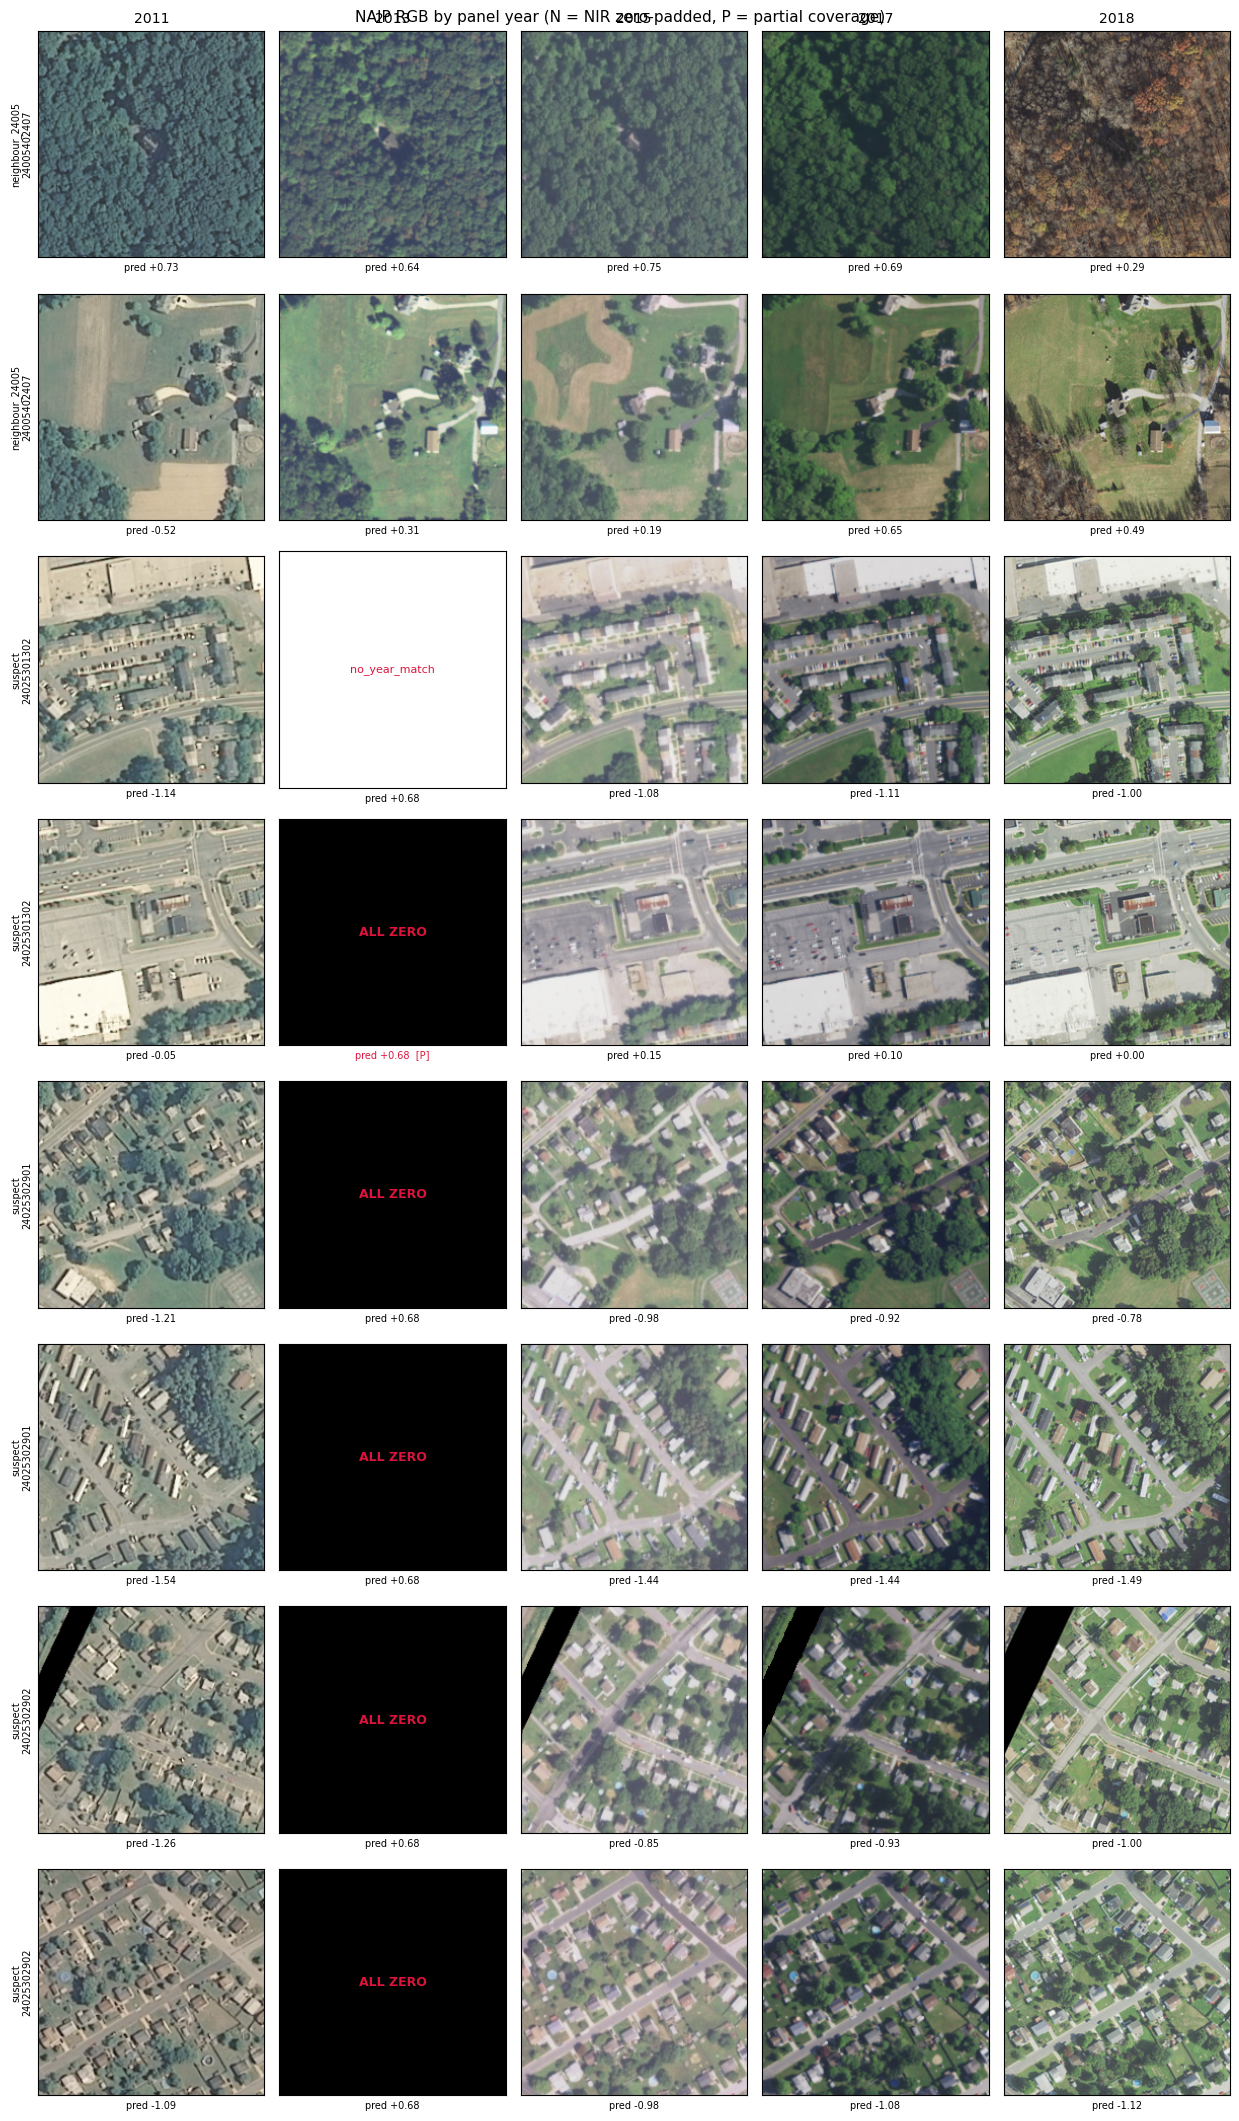

In [7]:
def show(band_mode="rgb"):
    """band_mode: 'rgb' (0,1,2) or 'nir' (band 3 alone).

    Calls plt.show() and returns None rather than returning the figure: under a
    non-interactive backend a returned figure only prints its repr, which is
    what made this look like it did nothing.
    """
    n_r, n_c = len(targets), len(PANEL_YEARS)
    fig, axes = plt.subplots(n_r, n_c, figsize=(2.5 * n_c, 2.7 * n_r),
                             squeeze=False)
    for r, t in enumerate(targets.itertuples()):
        for c, year in enumerate(PANEL_YEARS):
            ax = axes[r][c]
            ax.set_xticks([]); ax.set_yticks([])
            crop = crops.get((t.building_id, year))
            m = meta[(meta.building_id == t.building_id) & (meta.year == year)]
            m = m.iloc[0] if len(m) else None
            if crop is None:
                ax.text(0.5, 0.5, m.failure if m is not None else "none",
                        ha="center", va="center", color="crimson", fontsize=8)
            else:
                if band_mode == "rgb":
                    ax.imshow(np.transpose(crop[:3], (1, 2, 0)),
                              vmin=0, vmax=255)
                else:
                    ax.imshow(crop[3] if crop.shape[0] > 3
                              else np.zeros(crop.shape[1:]),
                              cmap="gray", vmin=0, vmax=255)
                # An all-zero crop is indistinguishable from a dark image by
                # eye, and it is the whole point of this notebook — label it.
                if not crop.any():
                    ax.text(0.5, 0.5, "ALL ZERO", ha="center", va="center",
                            transform=ax.transAxes, color="crimson",
                            fontsize=9, fontweight="bold")
            if r == 0:
                ax.set_title(str(year), fontsize=10)
            if c == 0:
                ax.set_ylabel(f"{t.group}\n{t.GEOID}", fontsize=7)
            if m is not None:
                flags = "".join(["N" if m.nir_padded else "",
                                 "P" if m.partial else ""])
                ax.set_xlabel(f"pred {m.pred:+.2f}"
                              + (f"  [{flags}]" if flags else ""), fontsize=7,
                              color="crimson" if flags else "black")
    fig.suptitle(f"NAIP {band_mode.upper()} by panel year "
                 "(N = NIR zero-padded, P = partial coverage)", fontsize=11)
    fig.tight_layout()
    plt.show()

show("rgb")

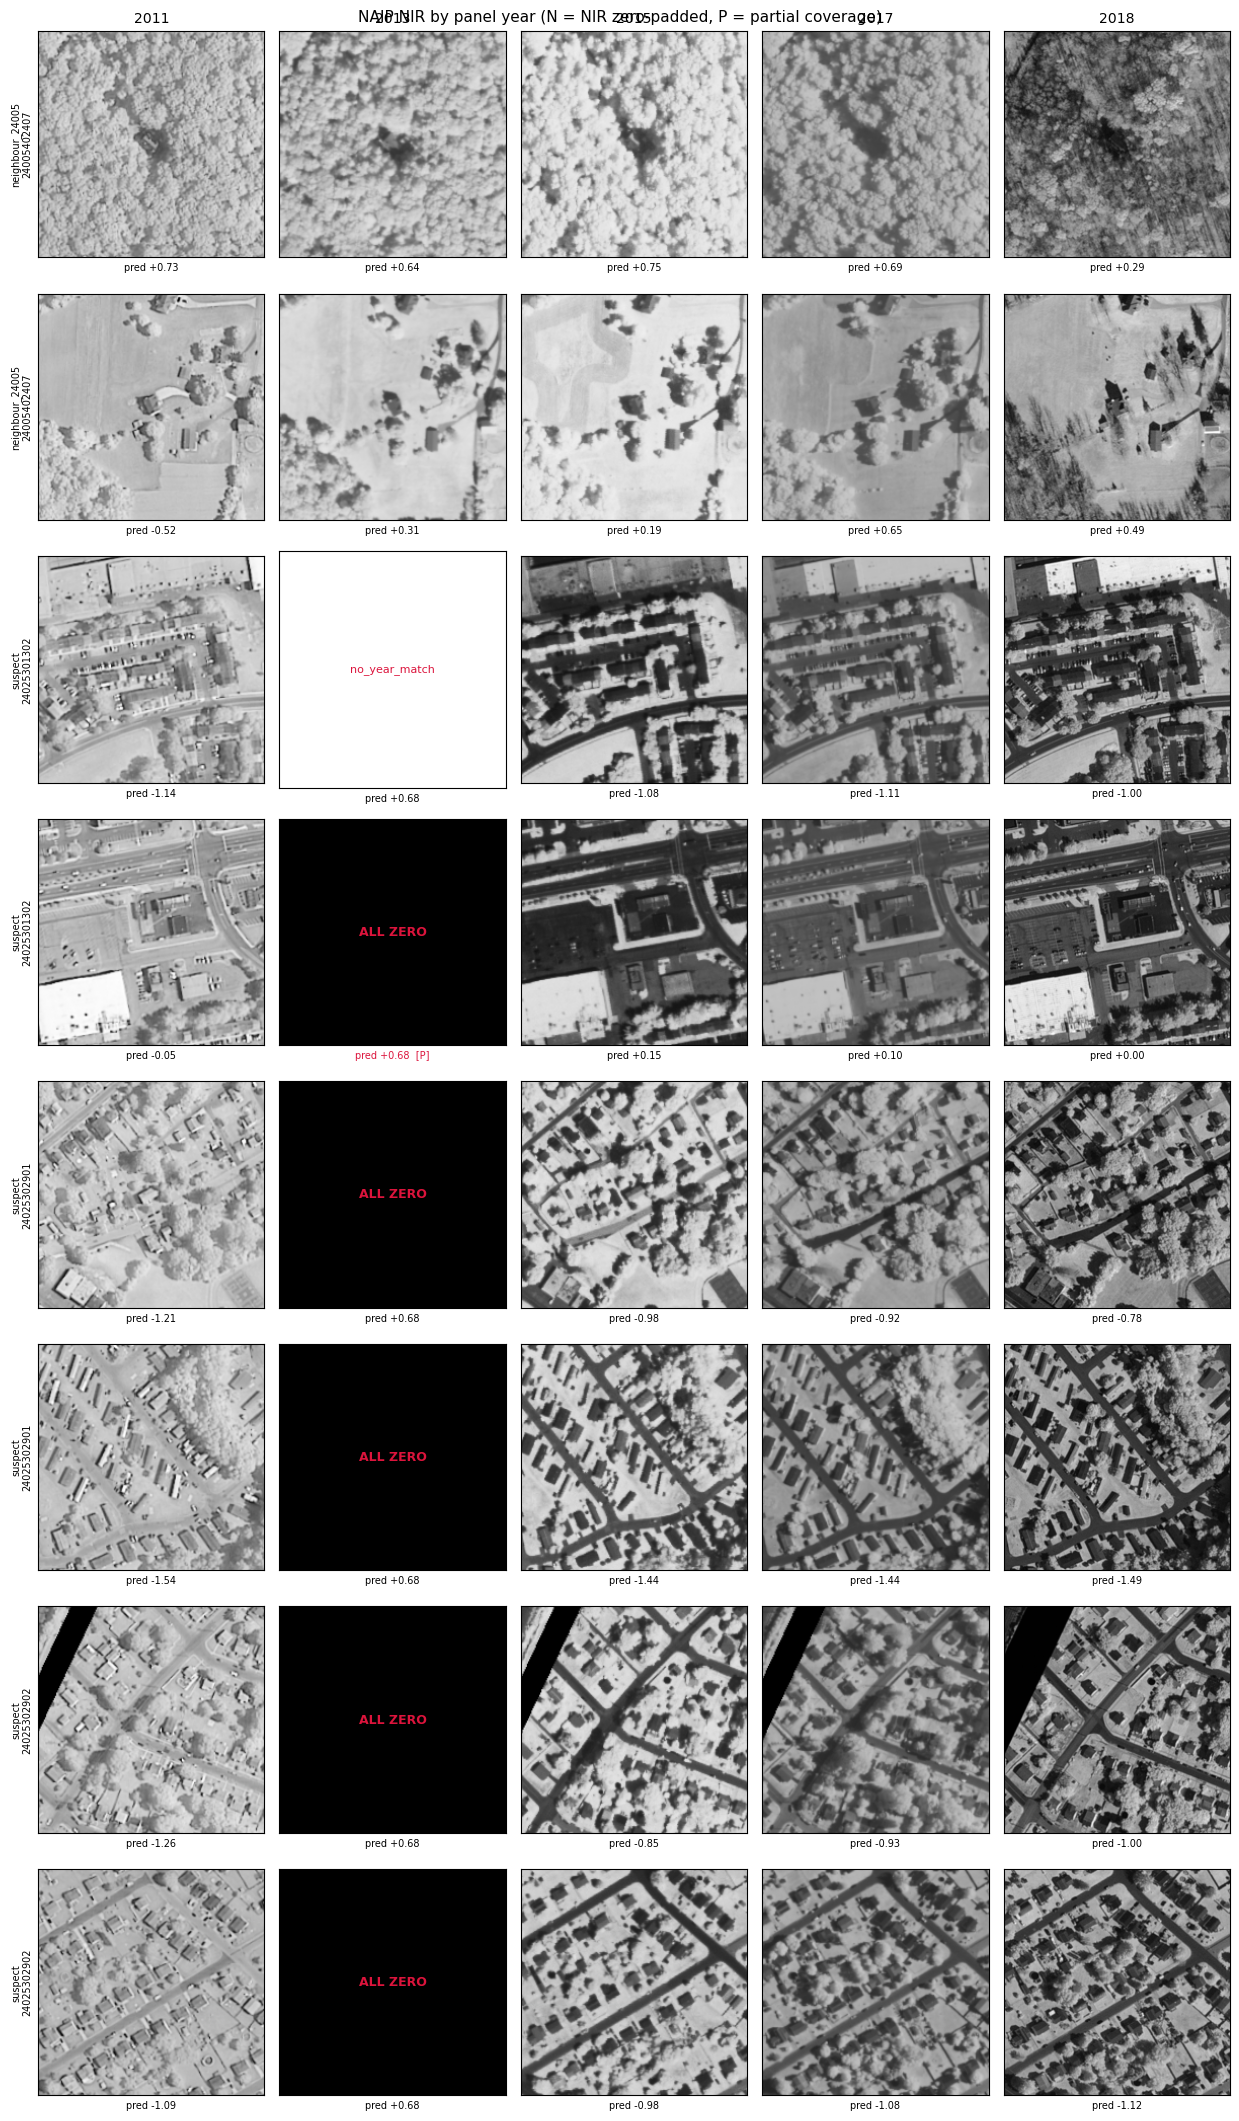

In [8]:
# NIR alone. Section 6 already showed the suspect 2013 crops are all zero in
# every band, so expect a solid black column with "ALL ZERO" stamped on it.
show("nir")

## 6. Radiometry, without eyeballing

Per-band mean/std by year and group. A season change (leaf-off vs leaf-on), a sensor change or a zero NIR band all show up as a step in these numbers, and they are easier to argue from than a picture.

In [9]:
stats = []
for (bid, year), crop in crops.items():
    if crop is None:
        continue
    g = targets.loc[targets.building_id == bid, "group"].iloc[0]
    row = {"group": g, "year": year, "building_id": bid}
    for i, band in enumerate(["R", "G", "B", "NIR"][:crop.shape[0]]):
        row[f"{band}_mean"] = float(crop[i].mean())
        row[f"{band}_std"] = float(crop[i].std())
    stats.append(row)

stats = pd.DataFrame(stats)
print("per-band mean by group x year")
display(stats.groupby(["group", "year"])[
    [c for c in stats.columns if c.endswith("_mean")]].mean().round(1))
print("per-band std by group x year (contrast/sharpness)")
display(stats.groupby(["group", "year"])[
    [c for c in stats.columns if c.endswith("_std")]].mean().round(1))

per-band mean by group x year


R_mean  G_mean  B_mean  NIR_mean
group           year                                  
neighbour_24005 2011   106.7   120.9   117.2     177.8
                2013   105.2   122.6   115.7     181.9
                2015   111.5   123.7   115.7     201.0
                2017    68.4    86.4    68.3     150.4
                2018   107.8   102.2    81.8     126.1
suspect         2011   142.4   145.2   133.5     171.0
                2013     0.0     0.0     0.0       0.0
                2015   157.2   158.3   151.7     133.4
                2017   102.5   109.7   103.7     116.3
                2018   135.3   146.5   128.0     102.5

per-band std by group x year (contrast/sharpness)


R_std  G_std  B_std  NIR_std
group           year                              
neighbour_24005 2011   27.2   25.2   22.1     26.9
                2013   25.1   26.7   14.4     33.6
                2015   24.0   21.4   15.9     38.0
                2017   22.9   22.1   13.6     29.8
                2018   31.3   28.9   21.7     38.4
suspect         2011   42.6   38.0   34.6     36.7
                2013    0.0    0.0    0.0      0.0
                2015   39.3   34.6   34.4     62.1
                2017   44.2   38.3   37.7     43.4
                2018   47.0   43.5   42.8     56.5

## 7. Confirmed: the 2013 crops are all zero

Section 6 settles it. For the suspect Harford tracts in 2013:

```
                      R_mean  G_mean  B_mean  NIR_mean      R_std  G_std  B_std  NIR_std
suspect      2013        0.0     0.0     0.0       0.0        0.0    0.0    0.0      0.0
             2015      157.2   158.3   151.7     133.4       39.3   34.6   34.4     62.1
neighbour    2013      105.2   122.6   115.7     181.9       25.1   26.7   14.4     33.6
```

**Every band, mean 0 and std 0 — the model was handed solid black 224x224 images and returned its fixed response to them, `0.68359375`.** Nothing subtle about the imagery; there are no pixels.

### The hypothesis in the header was wrong, and the correction matters

I guessed zero-fill from a boundless read (`partial_coverage`). Section 4 rules that out: for almost every suspect crop the fetch reports `failure=None`, `partial=False`, `nir_padded=False`, and section 3 shows `covers_window=True` with a normal 4-band `image` asset. The requested window sits **inside** the DOQQ, the read succeeds, and the DOQQ itself contains **nodata over that area**. NAIP 2013 has a coverage hole across part of Harford County — visible too in section 3, where 24025301302 has one item in 2013 against four in 2011/2015/2017.

So `reject_partial_coverage` would **not** have caught this. Neither would any metadata check: the STAC item looks perfectly healthy.

### The guard that does work

The only reliable detector is the **content of the returned array**. In `naip_fetcher.read_naip_crop_from_src`, after the read:

```python
# A crop with no variance carries no information: NAIP nodata holes read back
# as a valid array of zeros, with the item present, the window inside the
# raster and every existing flag clear. Only the pixels reveal it.
if not crop.any():
    _count("blank_crop")
    return None, nir_padded, partial, "blank_crop"
```

`blank_crop` then joins `no_items` / `no_year_match` in `PERMANENT_FAILURES`, and `_extract_raw_image` drops the building like any other failed fetch. A near-constant test (`crop.std() < eps`) would also catch partially-holed crops, at the cost of a threshold to defend — start with the exact-zero test, which is unambiguous.

Worth noting separately: building `2341637194737822617` returns `no_year_match` under `exact_year=True` here, yet carries a prediction of `0.684` in the 2013 CSV. Whatever path produced that value was not applying the strict year guard.

### For this run

1. Add the `blank_crop` guard and re-predict Baltimore. The affected buildings become missing rather than wrong, and `tract_outcomes` already drops non-finite predictions.
2. Until then, treat Harford 2013 as unobserved — the tracts in `CONST_TRACTS` from section 2b are the exact list.

### For the scale-up

This is the part that generalizes. A NAIP nodata hole produced ~3,900 confidently wrong building scores, and **every existing diagnostic reported success**: `actual_year` correct, no failure, no flags, plausible-looking output value. The cheap standing checks:

* `blank_crop` rate per (city, year) persisted into the prediction summary — `get_fetch_stats()` already has the counter machinery.
* Modal-predicted-value share per (city, year), exactly as computed in section 2b. Harford 2013 shows 0.39 against a background of 0.002-0.016; no threshold tuning needed to see that.

### Effect on the event study

Baltimore's post-treatment ATT is stable at 0.086-0.091 whether or not Harford is included. What this corrupts is the **pre-trend test**, because Harford is 6.5% of the never-treated controls but 25-60% of the late cohorts that identify k = -2 and k = -3. So fixing it changes the diagnostics, not the headline.